<a href="https://colab.research.google.com/github/envirodatascience/final-project-pargoal-kei-team/blob/main/final_project_pargoal_kei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from plotnine import *
import plotnine
import numpy as np

import geopandas as gpd
from shapely.geometry import Polygon

In [2]:
# Upload Heat Pump Data - use this one 4/26
url = "https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/refs/heads/main/WS%20Map_all.csv"
hp_df = pd.read_csv(url)  # Try different encoding
hp_df.head()
hp_df.value_counts()

Legal Town     Heat Pump Type                    RNC      Sector  Source Program Name  Utility     Year  LEGAL TOWN     Program   Source Program              Project Measure: Measure Total Quantity
West Hartford  Air Source Heat Pump, Ducted      Not RNC  RES     RES HVAC             Eversource  2023  WEST HARTFORD  Tracksys  Energy Optimization Rebate  1                                          243
Stamford       Air Source Heat Pump, Ducted      Not RNC  RES     RES HVAC             Eversource  2023  STAMFORD       Tracksys  Energy Optimization Rebate  1                                          243
West Hartford  Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             Eversource  2021  WEST HARTFORD  Tracksys  Energy Optimization Rebate  1                                          224
                                                                                                   2022  WEST HARTFORD  Tracksys  Energy Optimization Rebate  1                                          221
Guilford       Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             Eversource  2021  GUILFORD       Tracksys  Energy Optimization Rebate  1                                          207
                                                                                                                                                                                                        ... 
Ansonia        Air Source Heat Pump, Mini Split  Not RNC  C&I     ECB                  UI          2023  ANSONIA        EXP       EXP                         2                                            1
                                                                                                                                                              3                                            1
                                                                                                                        MID       MID                         1                                            1
Woodbury       Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             Eversource  2021  WOODBURY       Tracksys  Energy Optimization Rebate  2                                            1
Ansonia        Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             UI          2020  ANSONIA        CTDSHP    CTDSHP                      1                                            1
Name: count, Length: 2810, dtype: int64

# Understanding Heat Pump Data

In [3]:
hp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54814 entries, 0 to 54813
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Legal Town                               54814 non-null  object
 1   Heat Pump Type                           54814 non-null  object
 2   RNC                                      54814 non-null  object
 3   Sector                                   54814 non-null  object
 4   Source Program Name                      41362 non-null  object
 5   Utility                                  54814 non-null  object
 6   Year                                     54814 non-null  int64 
 7   LEGAL TOWN                               54814 non-null  object
 8   Program                                  54814 non-null  object
 9   Source Program                           41362 non-null  object
 10  Project Measure: Measure Total Quantity  54814 non-null  i

In [4]:
hp_df.shape

(54814, 11)

In [5]:
hp_df['Heat Pump Type'].value_counts()

,count
Heat Pump Type,
"Air Source Heat Pump, Mini Split",40567
"Air Source Heat Pump, Ducted",13354
Ground Source Heat Pump,893


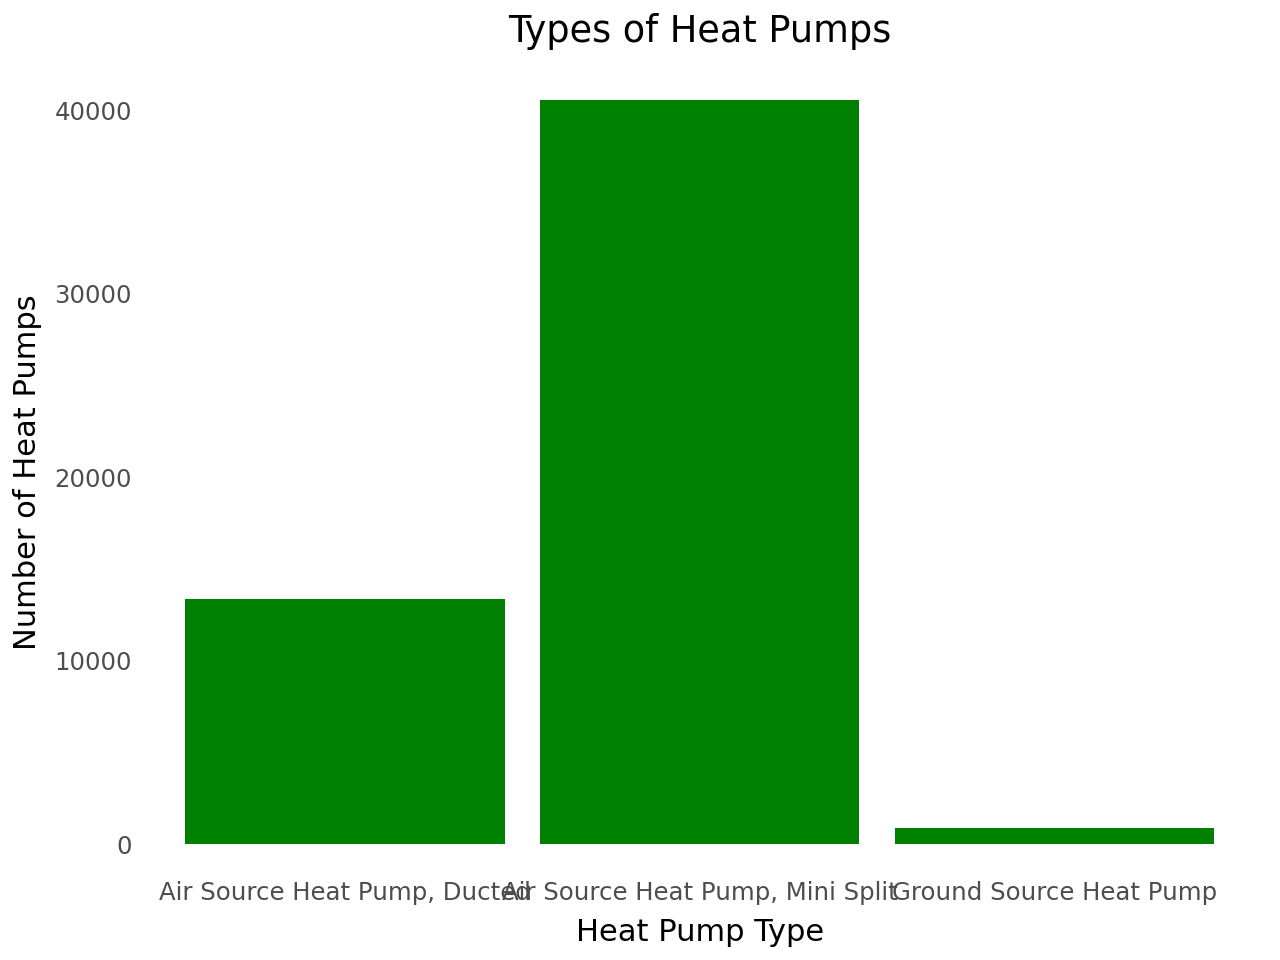

In [6]:
# Plotting by heat pump type
from plotnine import ggplot, aes, geom_bar, labs

plot = (
    ggplot(hp_df, aes(x='Heat Pump Type')) +
    geom_bar(fill="green") +   # <-- set the fill color directly here
    labs(title='Types of Heat Pumps', x='Heat Pump Type', y='Number of Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)
plot


In [7]:
# Legal town is all capitizaled so need to change it to lower case
#hp_df[""]
hp_df.Year.value_counts()

,count
Year,
2023,18920
2022,11342
2021,9677
2020,5163
2019,4366
2018,3108
2017,2238


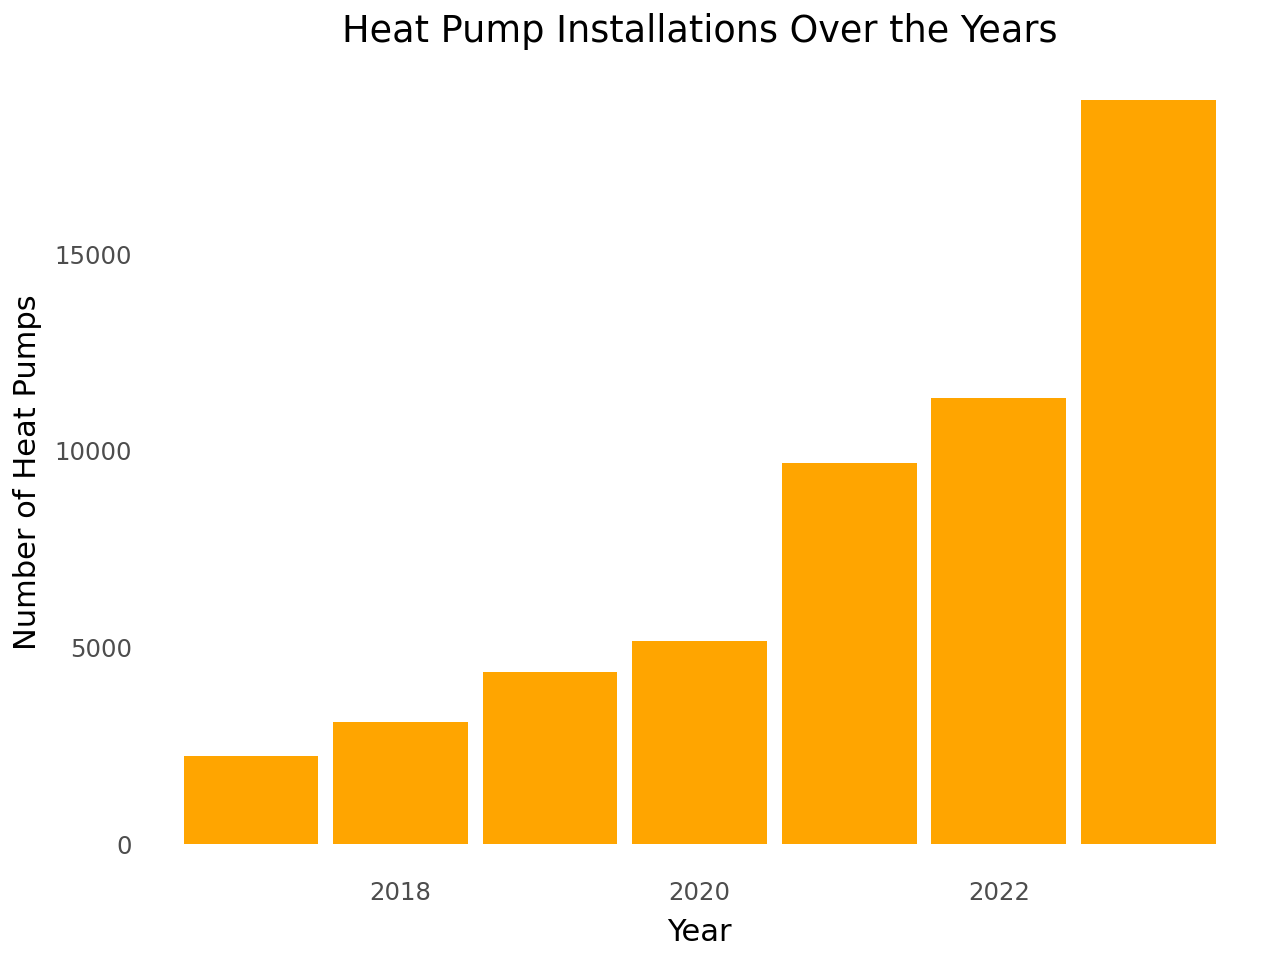

In [8]:
# Plotting by Years
plot = (
    ggplot(hp_df, aes(x='Year')) +
    geom_bar(fill="orange") +
    labs(title='Heat Pump Installations Over the Years', x='Year', y='Number of Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)
plot

In [9]:
hp_df.Utility.value_counts()

,count
Utility,
Eversource,48378
UI,6436


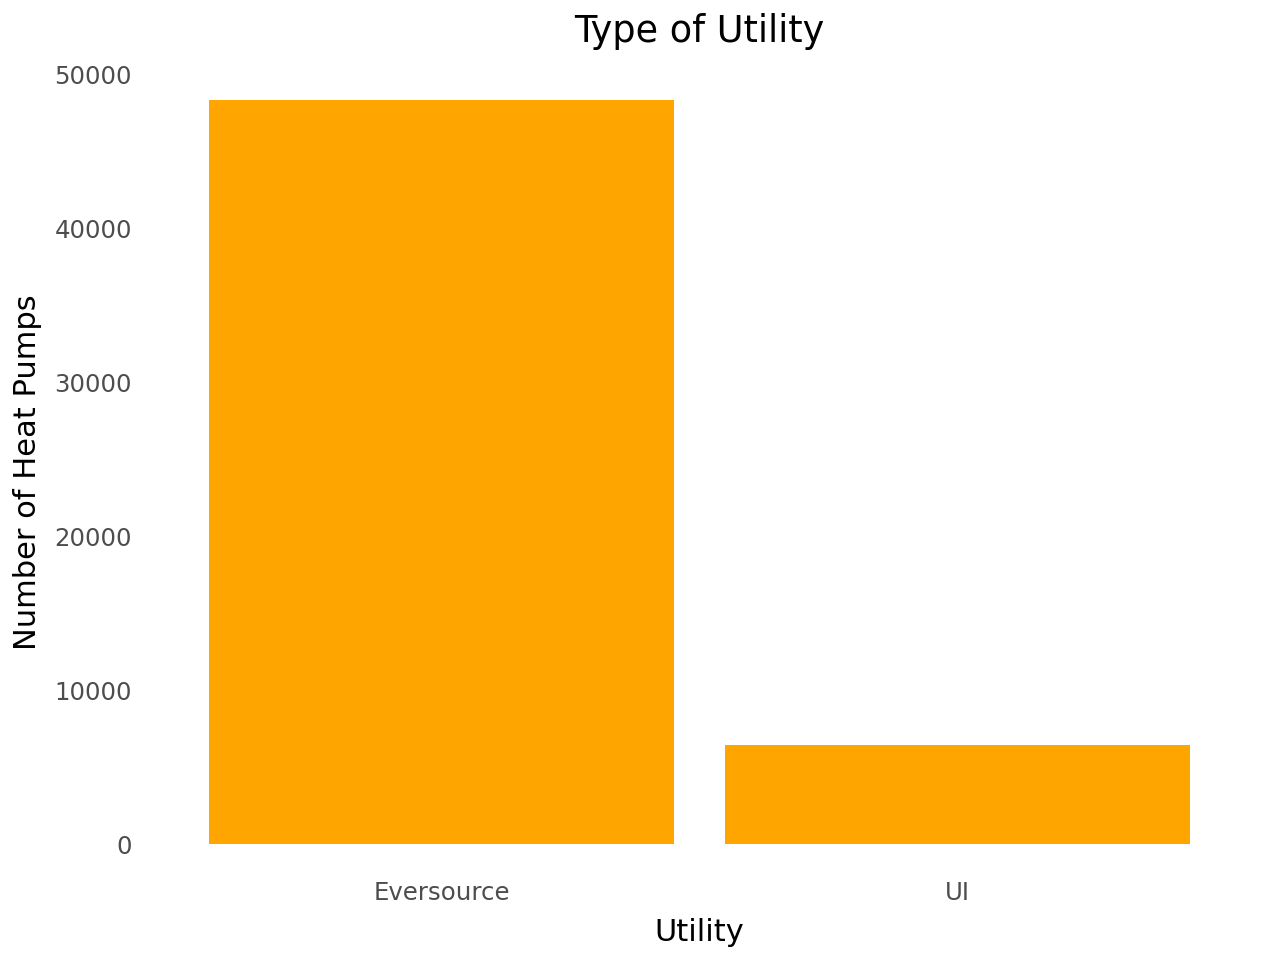

In [10]:
# Plotting by utility
plot = (
    ggplot(hp_df, aes(x='Utility')) +
    geom_bar(fill="orange") +
    labs(title='Type of Utility', x='Utility', y='Number of Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)
plot

In [11]:
# Aggregating the years and heat pump type

# Group by 'Legal Town' and sum the 'Project Measure: Measure Total Quantity'
combined_hp = hp_df.groupby('Legal Town')['Project Measure: Measure Total Quantity'].sum().reset_index()

# Rename the column if you want
combined_hp = combined_hp.rename(columns={'Project Measure: Measure Total Quantity': 'Total Heat Pumps'})
combined_hp = combined_hp.rename(columns={'Legal Town': 'TOWN'})


# View result
combined_hp.head()


,TOWN,Total Heat Pumps
0,Andover,95
1,Ansonia,115
2,Ashford,192
3,Avon,445
4,Barkhamsted,103


In [12]:
# check for NAs
combined_hp.isna().sum()

,0
TOWN,0
Total Heat Pumps,0


In [13]:
# Group by Legal Town and aggregate Utility into a combined string
combined_utilities = hp_df.groupby('Legal Town')['Utility'].unique().reset_index()
combined_utilities['Utility'] = combined_utilities['Utility'].apply(lambda x: ', '.join(x))

print(combined_utilities)
combined_utilities

        Legal Town     Utility
0          Andover  Eversource
1          Ansonia          UI
2          Ashford  Eversource
3             Avon  Eversource
4      Barkhamsted  Eversource
..             ...         ...
161  Windsor Locks  Eversource
162        Wolcott  Eversource
163     Woodbridge          UI
164       Woodbury  Eversource
165      Woodstock  Eversource

[166 rows x 2 columns]


,Legal Town,Utility
0,Andover,Eversource
1,Ansonia,UI
2,Ashford,Eversource
3,Avon,Eversource
4,Barkhamsted,Eversource
...,...,...
161,Windsor Locks,Eversource
162,Wolcott,Eversource
163,Woodbridge,UI
164,Woodbury,Eversource


In [14]:
# number of Legal Towns
combined_hp['TOWN'].nunique()

166

In [15]:
# Uploading Demographic Data (2023)
url = "https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/refs/heads/main/CT_demoU.csv"
demo_df = pd.read_csv(url)
demo_df.head()

,TOWN,Median Age,Median Home Value,Unemployment Rate,Per Income Capita,Tenure_Owner_Occupied(%),Tenure_Renter_Occupied(%),Housing Units,TOWN_NO,COUNTY,...,60_to_64_Years,18_to_24_Years,65_and_Over_Years,Total_Households,Median_Household_Income,SNAP_Recipients,Utility_gas,Bottled_tank_or_LP_gas,Electricity,Fuel_oil_kerosene_etc.
0,Andover,47.9,297400,4.7,44803,88.40,11.60,1275.0,1.0,Tolland,...,9.6,9.5,17.7,1216.0,99449.0,2.88,1.4,7.9,5.1,74.6
1,Ansonia,42.4,217800,9.6,30285,59.42,40.58,8867.0,2.0,New Haven,...,8.4,6.5,18.4,7806.0,53709.0,15.60,48.6,1.5,7.9,40.6
2,Ashford,37.8,271700,4.9,46602,73.68,26.32,2033.0,3.0,Windham,...,7.4,7.0,14.2,1774.0,84909.0,8.23,1.1,2.7,16.6,62.6
3,Avon,45.2,371900,4.1,74617,83.27,16.73,8042.0,4.0,Hartford,...,7.6,5.0,20.9,6977.0,123077.0,2.85,43.1,4.5,8.8,42.5
4,Barkhamsted,48.3,262900,5.0,43558,92.66,7.34,1473.0,5.0,Litchfield,...,5.9,6.0,24.0,1336.0,103500.0,2.10,0.7,2.8,7.4,80.7


In [16]:
# subset to just Town, Median Home Value, and Tenure_Owner_Occupied(%), and Tenure_Renter_Occupied(%)
demo_df = demo_df[['TOWN', 'Median_Household_Income', 'Tenure_Owner_Occupied(%)']]
demo_df.head()

,TOWN,Median_Household_Income,Tenure_Owner_Occupied(%)
0,Andover,99449.0,88.40
1,Ansonia,53709.0,59.42
2,Ashford,84909.0,73.68
3,Avon,123077.0,83.27
4,Barkhamsted,103500.0,92.66


In [17]:
# how many towns in demo_df
demo_df['TOWN'].nunique()

170

In [18]:
# check for NAs
demo_df.isna().sum()

,0
TOWN,0
Median_Household_Income,28
Tenure_Owner_Occupied(%),0


In [19]:
# remove NAs
demo_df = demo_df.dropna()

In [20]:
demo_df.isna().shape
# 142 towns left

(142, 3)

# Joining both Demographic Data and Heat Pump Data

In [21]:
joined_df = pd.merge(combined_hp, demo_df, on='TOWN', how='right')
joined_df.head()

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%)
0,Andover,95.0,99449.0,88.40
1,Ansonia,115.0,53709.0,59.42
2,Ashford,192.0,84909.0,73.68
3,Avon,445.0,123077.0,83.27
4,Barkhamsted,103.0,103500.0,92.66


In [22]:
joined_df.shape

(142, 4)

In [23]:
# remove all NAs
joined_df = joined_df.dropna()

In [24]:
joined_df.shape
# end up with 139 towns left that have both income, renters, and

(139, 4)

In [25]:
# create new column for above or below national average of home ownership
joined_df['Above_National_Average'] = joined_df['Tenure_Owner_Occupied(%)'] > 66
joined_df.head()

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%),Above_National_Average
0,Andover,95.0,99449.0,88.40,True
1,Ansonia,115.0,53709.0,59.42,False
2,Ashford,192.0,84909.0,73.68,True
3,Avon,445.0,123077.0,83.27,True
4,Barkhamsted,103.0,103500.0,92.66,True


# Analysis

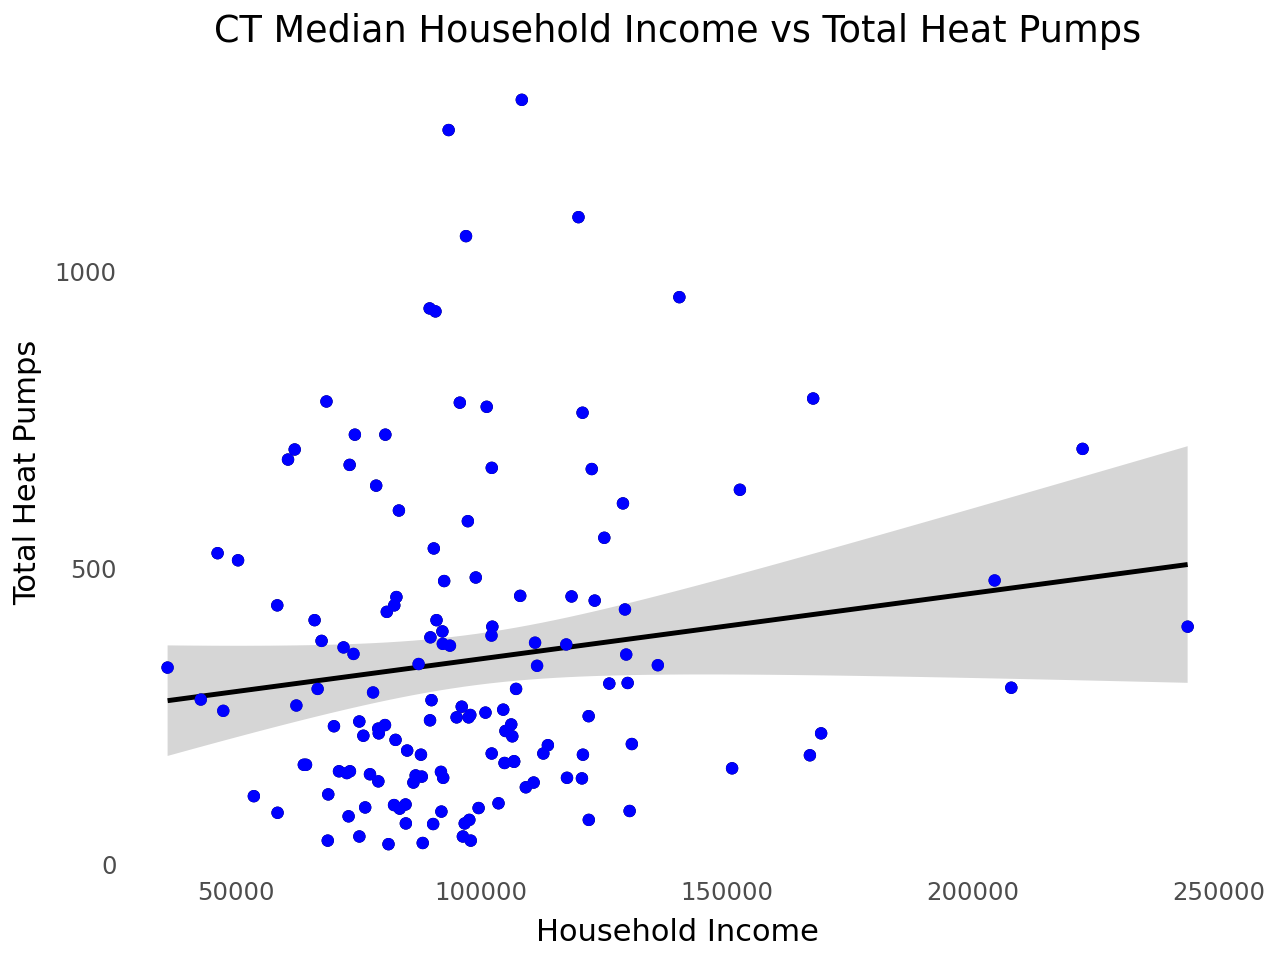

In [26]:
# create plot comparing household income and total heat pumps
(
    ggplot(joined_df, aes(x='Median_Household_Income', y='Total Heat Pumps')) +
    geom_point() +
    geom_smooth(method='lm') +
    theme_minimal() +
    geom_point(color="blue") +
    labs(title='CT Median Household Income vs Total Heat Pumps', x='Household Income', y='Total Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)

In [27]:
# do linear regression test to see correlation
import statsmodels.api as sm

# define model
model = sm.OLS(joined_df['Total Heat Pumps'], joined_df['Median_Household_Income'])

# fit model
results = model.fit()

# print results
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:       Total Heat Pumps   R-squared (uncentered):                   0.619
Model:                            OLS   Adj. R-squared (uncentered):              0.616
Method:                 Least Squares   F-statistic:                              223.7
Date:                Sat, 26 Apr 2025   Prob (F-statistic):                    1.14e-30
Time:                        23:22:32   Log-Likelihood:                         -973.25
No. Observations:                 139   AIC:                                      1948.
Df Residuals:                     138   BIC:                                      1951.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [28]:
# second analysis - T-test
import scipy.stats as stats

stats.ttest_ind(joined_df['Total Heat Pumps'][joined_df['Above_National_Average'] == True],
                joined_df['Total Heat Pumps'][joined_df['Above_National_Average'] == False])

TtestResult(statistic=np.float64(-1.9130508408116251), pvalue=np.float64(0.05782804761765743), df=np.float64(137.0))

## Uploading Spatial Data - CT Shapefile

In [29]:
# This works
!wget -O tl_2020_09_place20.zip "https://www2.census.gov/geo/tiger/TIGER2020/PLACE/tl_2020_09_place.zip"


--2025-04-26 23:22:32--  https://www2.census.gov/geo/tiger/TIGER2020/PLACE/tl_2020_09_place.zip
Resolving www2.census.gov (www2.census.gov)... 172.65.90.24, 172.65.90.27, 172.65.90.25, ...
Connecting to www2.census.gov (www2.census.gov)|172.65.90.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 867378 (847K) [application/zip]
Saving to: ‘tl_2020_09_place20.zip’

tl_2020_09_place20. 100%[===================>] 847.05K  --.-KB/s    in 0.1s    

2025-04-26 23:22:33 (6.20 MB/s) - ‘tl_2020_09_place20.zip’ saved [867378/867378]



In [30]:
# unzip
!unzip tl_2020_09_place20.zip

Archive:  tl_2020_09_place20.zip
 extracting: tl_2020_09_place.cpg    
  inflating: tl_2020_09_place.dbf    
  inflating: tl_2020_09_place.prj    
  inflating: tl_2020_09_place.shp    
  inflating: tl_2020_09_place.shp.ea.iso.xml  
  inflating: tl_2020_09_place.shp.iso.xml  
  inflating: tl_2020_09_place.shx    


In [31]:
shape = 'tl_2020_09_place.shp'
df_CT = gpd.read_file(shape)
df_CT.head()

,STATEFP,PLACEFP,PLACENS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,PCINECTA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,09,18780,02378272,0918780,Danielson,Danielson borough,21,C1,N,N,G4110,A,2832746,169737,+41.8065910,-071.8846977,"POLYGON ((-71.8992 41.80843, -71.89893 41.8088..."
1,09,73700,02378292,0973700,Stonington,Stonington borough,21,C1,N,N,G4110,A,883234,1044461,+41.3347652,-071.8994587,"POLYGON ((-71.91199 41.33546, -71.91196 41.335..."
2,09,34180,02378275,0934180,Groton,Groton city,25,C1,N,N,G4110,A,7985936,9524722,+41.3250543,-072.0668616,"POLYGON ((-72.08962 41.3676, -72.08887 41.3675..."
3,09,39940,02378278,0939940,Jewett City,Jewett City borough,21,C1,N,N,G4110,A,1825133,98500,+41.6072025,-071.9797914,"POLYGON ((-71.99155 41.60553, -71.99091 41.606..."
4,09,56200,02378289,0956200,Norwich,Norwich city,25,C1,Y,Y,G4110,A,72680185,3483833,+41.5480059,-072.0894538,"POLYGON ((-72.14065 41.5365, -72.14055 41.5368..."


<Axes: >

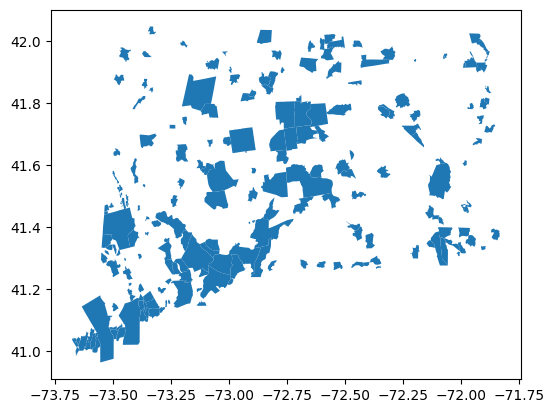

In [32]:
df_CT.plot()

In [33]:
df_CT.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   215 non-null    object  
 1   PLACEFP   215 non-null    object  
 2   PLACENS   215 non-null    object  
 3   GEOID     215 non-null    object  
 4   NAME      215 non-null    object  
 5   NAMELSAD  215 non-null    object  
 6   LSAD      215 non-null    object  
 7   CLASSFP   215 non-null    object  
 8   PCICBSA   215 non-null    object  
 9   PCINECTA  215 non-null    object  
 10  MTFCC     215 non-null    object  
 11  FUNCSTAT  215 non-null    object  
 12  ALAND     215 non-null    int64   
 13  AWATER    215 non-null    int64   
 14  INTPTLAT  215 non-null    object  
 15  INTPTLON  215 non-null    object  
 16  geometry  215 non-null    geometry
dtypes: geometry(1), int64(2), object(14)
memory usage: 28.7+ KB


In [34]:
df_CT.shape

(215, 17)

In [35]:
df_CT = df_CT.rename(columns={'NAME': 'TOWN'})



In [87]:
# 7:52
!wget -O Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip "https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/main/Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip"

--2025-04-26 23:52:19--  https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/main/Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3301614 (3.1M) [application/zip]
Saving to: ‘Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip’

Connecticut_and_Vic 100%[===================>]   3.15M  --.-KB/s    in 0.06s   

2025-04-26 23:52:19 (51.3 MB/s) - ‘Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip’ saved [3301614/3301614]



In [88]:
#7:52
!unzip Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip

Archive:  Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip
replace CT_Vicinity_Town_Polygon.cpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: CT_Vicinity_Town_Polygon.cpg  
replace CT_Vicinity_Town_Polygon.dbf? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: CT_Vicinity_Town_Polygon.dbf  
replace CT_Vicinity_Town_Polygon.prj? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: CT_Vicinity_Town_Polygon.prj  
replace CT_Vicinity_Town_Polygon.shp? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: CT_Vicinity_Town_Polygon.shp  
replace CT_Vicinity_Town_Polygon.shx? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: CT_Vicinity_Town_Polygon.shx  


In [46]:
# This works - 7:29 pm
#!wget -O Connecticut_and_Vicinity_Town.zip "https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/main/Connecticut_and_Vicinity_Town.zip"

--2025-04-26 23:30:34--  https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/main/Connecticut_and_Vicinity_Town.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3301614 (3.1M) [application/zip]
Saving to: ‘Connecticut_and_Vicinity_Town.zip’

Connecticut_and_Vic 100%[===================>]   3.15M  --.-KB/s    in 0.06s   

2025-04-26 23:30:34 (50.9 MB/s) - ‘Connecticut_and_Vicinity_Town.zip’ saved [3301614/3301614]



In [47]:
# This works - 7:29 pm
#!unzip Connecticut_and_Vicinity_Town.zip

Archive:  Connecticut_and_Vicinity_Town.zip
replace CT_Vicinity_Town_Polygon.cpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: CT_Vicinity_Town_Polygon.cpg  
replace CT_Vicinity_Town_Polygon.dbf? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: CT_Vicinity_Town_Polygon.dbf  
replace CT_Vicinity_Town_Polygon.prj? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: CT_Vicinity_Town_Polygon.prj  
replace CT_Vicinity_Town_Polygon.shp? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: CT_Vicinity_Town_Polygon.shp  
replace CT_Vicinity_Town_Polygon.shx? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: CT_Vicinity_Town_Polygon.shx  


In [90]:
shape = 'CT_Vicinity_Town_Polygon.shp'
df_CTT = gpd.read_file(shape)
df_CTT.head()

/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: CT_Vicinity_Town_Polygon.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.


,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry
0,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Uxbridge,True,Uxbridge,None,Uxbridge,"POLYGON ((1314474.251 950430.875, 1314007.251 ..."
1,Land,Other States,MA,Massachusetts,FIPS-COUNTY,21.0,Norfolk,TOWN-ID,Foxborough,True,Foxborough,None,Foxborough,"POLYGON ((1426805.375 949926.625, 1421795.625 ..."
2,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Southbridge,True,Southbridge,None,Southbridge,"POLYGON ((1205552.751 952445.875, 1205636.501 ..."
3,Land,Other States,MA,Massachusetts,FIPS-COUNTY,5.0,Bristol,TOWN-ID,Easton,True,Easton,None,Easton,"POLYGON ((1437395.589 928737.738, 1437395.589 ..."
4,Land,Other States,MA,Massachusetts,FIPS-COUNTY,13.0,Hamden,TOWN-ID,Agawam,True,Agawam,None,Agawam,"POLYGON ((1043830.001 959124.501, 1043763.375 ..."


In [94]:
CONN = df_CTT.STATE_COD == "CT"

,STATE_COD
0,False
1,False
2,False
3,False
4,False


In [79]:
df_CTT = df_CTT.rename(columns={'NAME': 'TOWN'})

In [84]:
print(df_CTT)

    STATEFP PLACEFP   PLACENS    GEOID             TOWN             NAMELSAD  \
0        09   18780  02378272  0918780        Danielson    Danielson borough   
1        09   73700  02378292  0973700       Stonington   Stonington borough   
2        09   34180  02378275  0934180           Groton          Groton city   
3        09   39940  02378278  0939940      Jewett City  Jewett City borough   
4        09   56200  02378289  0956200          Norwich         Norwich city   
..      ...     ...       ...      ...              ...                  ...   
210      09   86380  02631222  0986380    Wilton Center    Wilton Center CDP   
211      09   87140  02377884  0987140    Windsor Locks    Windsor Locks CDP   
212      09   87350  02377885  0987350          Winsted          Winsted CDP   
213      09   87455  02805996  0987455    Witches Woods    Witches Woods CDP   
214      09   87980  02377886  0987980  Woodbury Center  Woodbury Center CDP   

    LSAD CLASSFP PCICBSA PCINECTA  MTFC

In [80]:
df_CTT.shape

(215, 17)

In [81]:
df_CTT = df_CTT.dropna()

In [83]:
joined_df

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%),Above_National_Average
0,Andover,95.0,99449.0,88.40,True
1,Ansonia,115.0,53709.0,59.42,False
2,Ashford,192.0,84909.0,73.68,True
3,Avon,445.0,123077.0,83.27,True
4,Barkhamsted,103.0,103500.0,92.66,True
...,...,...,...,...,...
137,Windsor,393.0,92079.0,82.71,True
138,Wolcott,266.0,96014.0,84.86,True
139,Woodbridge,221.0,169155.0,88.09,True
140,Woodbury,256.0,100850.0,77.77,True


In [82]:
df = pd.merge(joined_df, df_CTT, on='TOWN', how='left')
df

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%),Above_National_Average,STATEFP,PLACEFP,PLACENS,GEOID,NAMELSAD,...,CLASSFP,PCICBSA,PCINECTA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,Andover,95.0,99449.0,88.40,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,Ansonia,115.0,53709.0,59.42,False,09,01150,02378267,0901150,Ansonia city,...,C1,N,N,G4110,A,15588608.0,435200.0,+41.3442494,-073.0698254,"POLYGON ((-73.10219 41.35302, -73.10202 41.353..."
2,Ashford,192.0,84909.0,73.68,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,Avon,445.0,123077.0,83.27,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,Barkhamsted,103.0,103500.0,92.66,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Windsor,393.0,92079.0,82.71,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
135,Wolcott,266.0,96014.0,84.86,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
136,Woodbridge,221.0,169155.0,88.09,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
137,Woodbury,256.0,100850.0,77.77,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [56]:
# geo
import geopandas as gpd

# plotting
from plotnine import *
import plotnine

In [72]:
#gdf['VALUE'] = gdf.index  # Example: just using the index as a value

# Create the map
map_plot = (
    ggplot() +
    geom_map(df_CTT, aes(geometry = 'geometry', fill = 'ALAND', color = 'pink') ) +

   # scale_fill_cmap('viridis') +
   # coord_fixed() +  # Maintains the correct aspect ratio
   # theme_minimal() +
    labs(title='Connecticut Towns', fill='Median_Household_Income')
)

# Display the plot
print(map_plot)
#map_plot

<ggplot: (1200 x 800)>


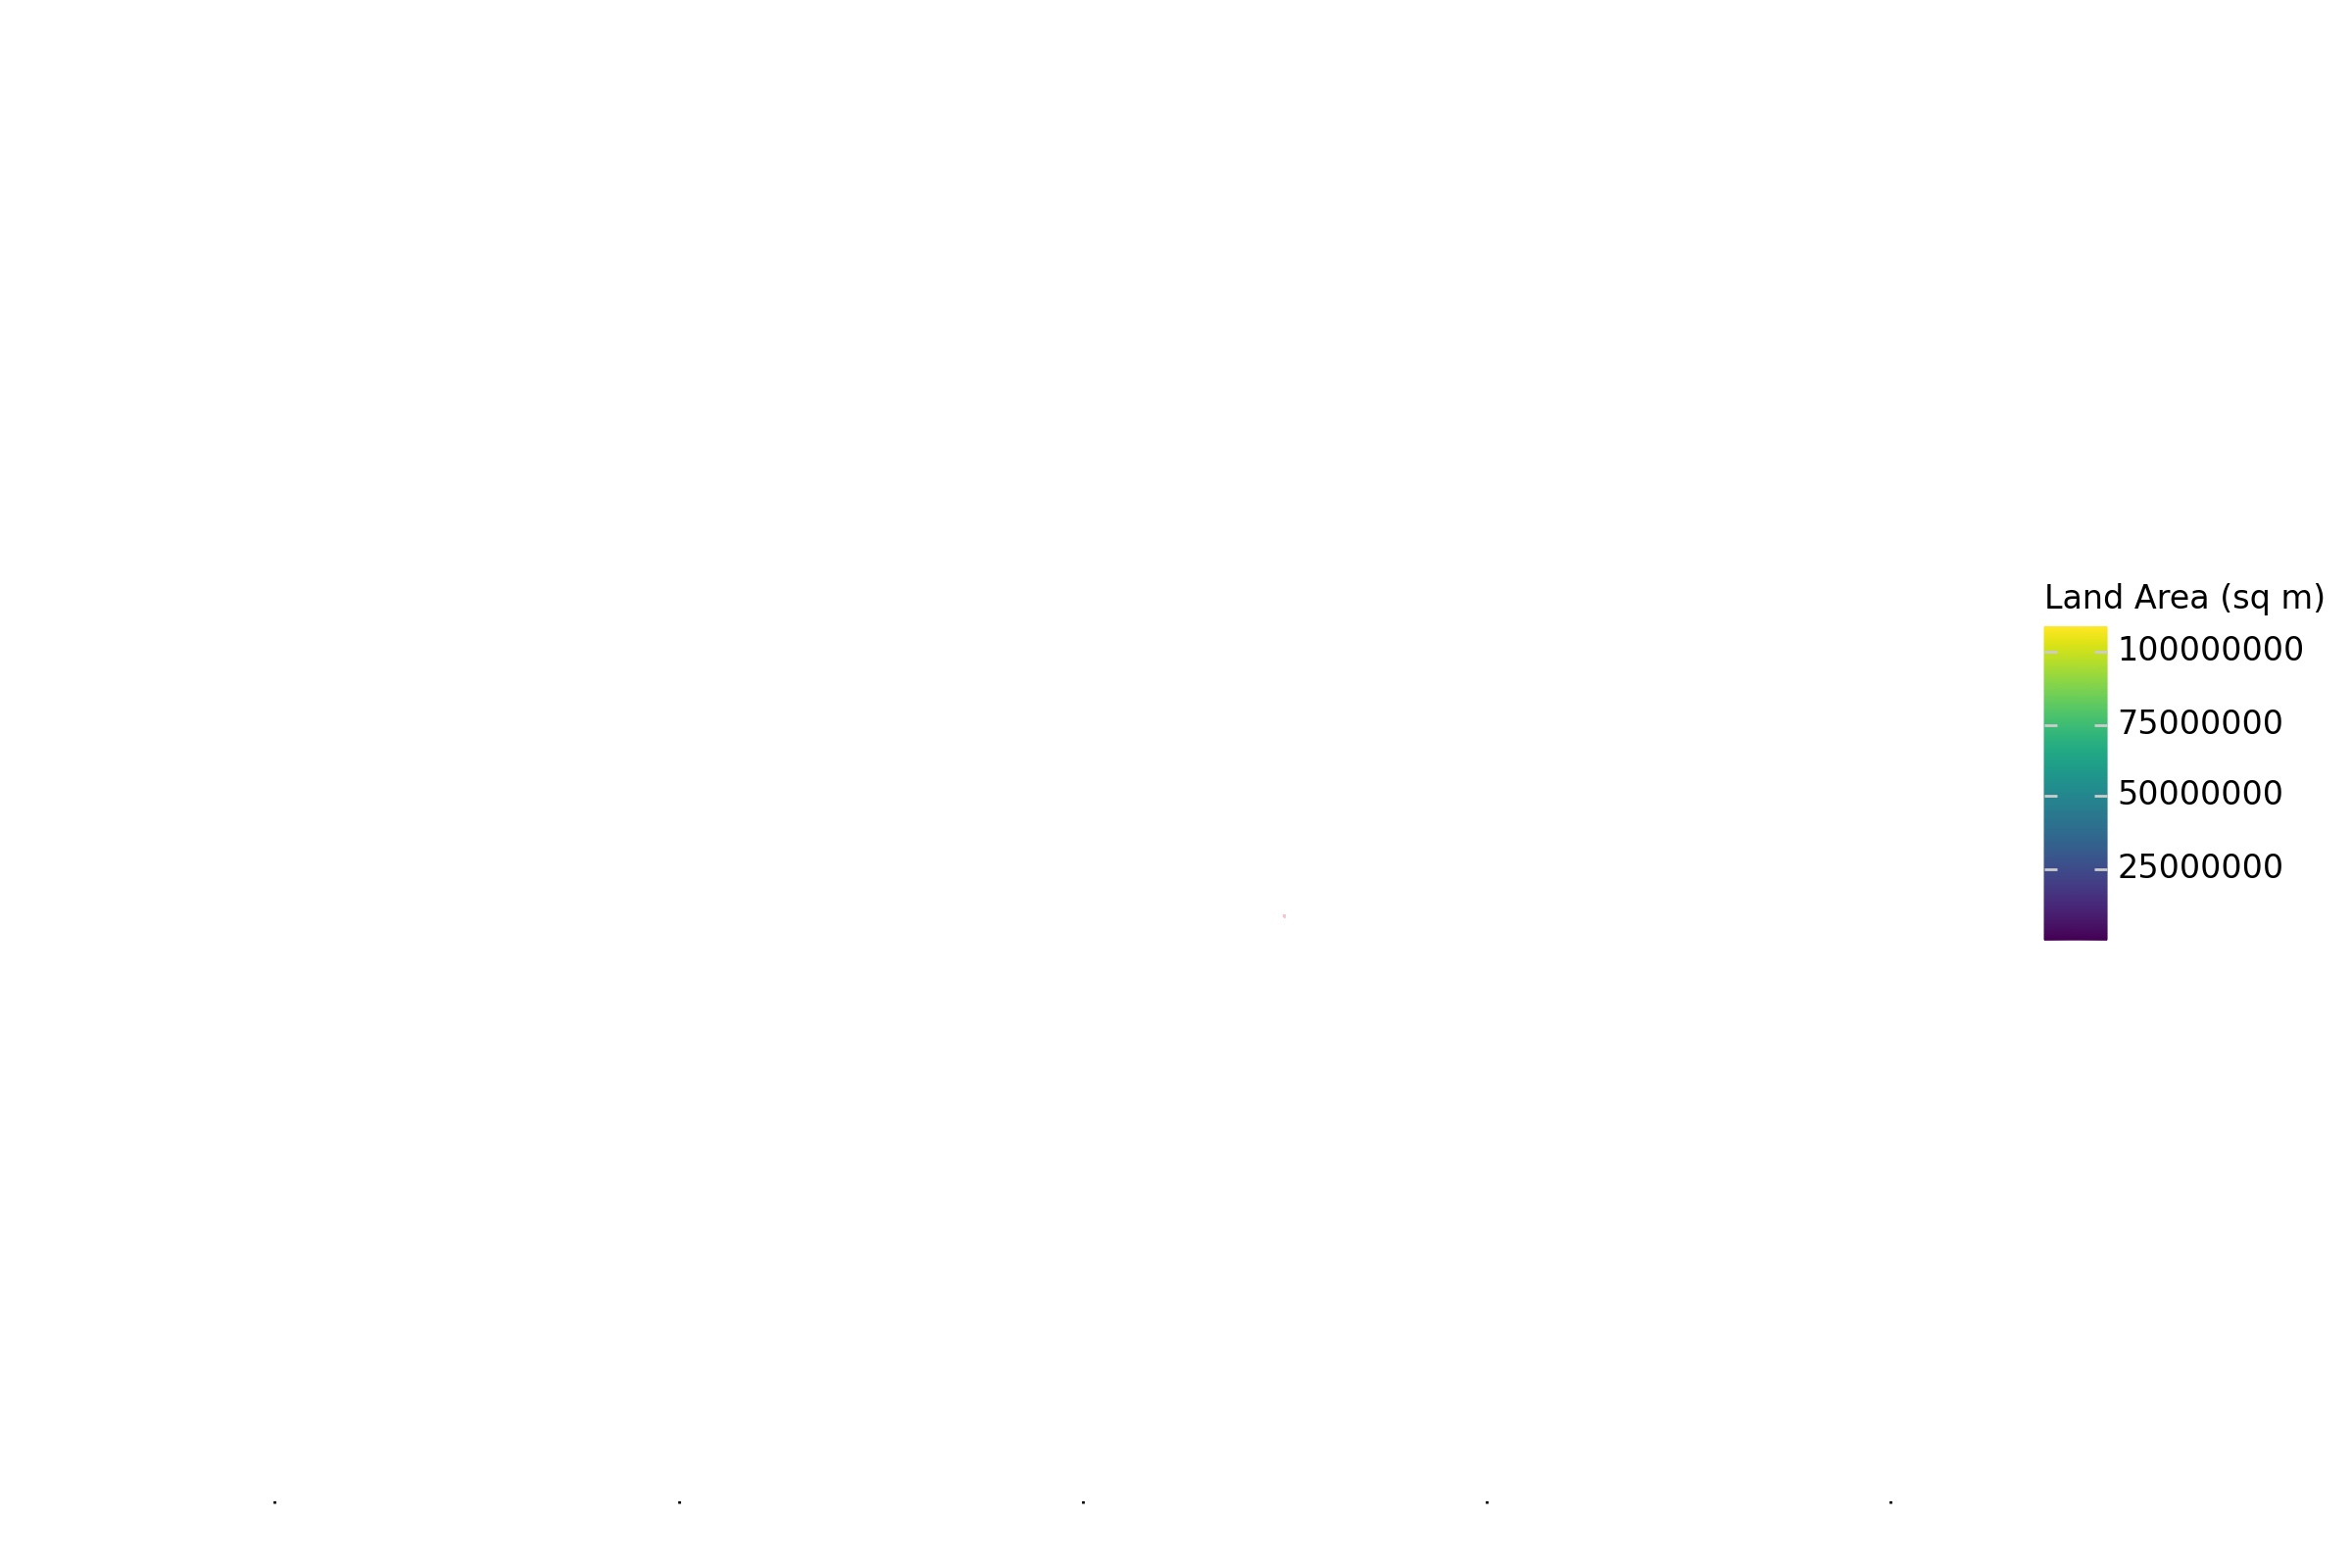

In [70]:
plotnine.options.figure_size = (12, 8)


(ggplot()
  + geom_map(df_CTT, aes(geometry = 'geometry', fill='ALAND'), color='pink')
  + xlim(-5e6,3e6)
  + ylim(-2.5e6, 4e6)
  + labs(fill='Land Area (sq m)')
  + theme_classic()
  + theme(axis_line=element_line(color="white"),
          axis_ticks=element_line(color = "white"),
          axis_text=element_line(color='white'),
          text=element_text(size = 12))
  # + xlab("")
  # + ylab("")
 )

<Axes: >

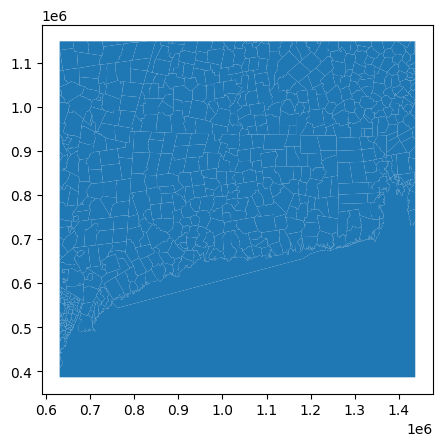

In [91]:
df_CTT.plot()

In [ ]:
#https://ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com/datasets/CTDEEP::connecticut-and-vicinity-town-boundary-set/explore?layer=1

In [40]:
!wget Connecticut_and_Vicinity_Town.zip "https://github.com/envirodatascience/final-project-pargoal-kei-team/blob/main/Connecticut_and_Vicinity_Town.zip"

--2025-04-26 23:27:28--  http://connecticut_and_vicinity_town.zip/
Resolving connecticut_and_vicinity_town.zip (connecticut_and_vicinity_town.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘connecticut_and_vicinity_town.zip’
--2025-04-26 23:27:28--  https://github.com/envirodatascience/final-project-pargoal-kei-team/blob/main/Connecticut_and_Vicinity_Town.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Connecticut_and_Vicinity_Town.zip’

Connecticut_and_Vic     [ <=>                ] 209.20K  --.-KB/s    in 0.04s   

2025-04-26 23:27:29 (5.12 MB/s) - ‘Connecticut_and_Vicinity_Town.zip’ saved [214217]

FINISHED --2025-04-26 23:27:29--
Total wall clock time: 0.5s
Downloaded: 1 files, 209K in 0.04s (5.12 MB/s)


In [41]:
!unzip Connecticut_and_Vicinity_Town.zip

Archive:  Connecticut_and_Vicinity_Town.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of Connecticut_and_Vicinity_Town.zip or
        Connecticut_and_Vicinity_Town.zip.zip, and cannot find Connecticut_and_Vicinity_Town.zip.ZIP, period.


In [36]:
# This works
!wget -O Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip "https://ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com/datasets/CTDEEP::connecticut-and-vicinity-town-boundary-set/explore?layer=1"


--2025-04-26 23:22:34--  https://ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com/datasets/CTDEEP::connecticut-and-vicinity-town-boundary-set/explore?layer=1
Resolving ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com (ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com)... 34.225.249.205, 3.215.20.206, 184.72.158.166
Connecting to ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com (ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com)|34.225.249.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58614 (57K) [text/html]
Saving to: ‘Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip’

Connecticut_and_Vic 100%[===================>]  57.24K  --.-KB/s    in 0.06s   

2025-04-26 23:22:35 (917 KB/s) - ‘Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip’ saved [58614/58614]



In [38]:
# unzip
!unzip Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip
#!unzip Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip

Archive:  Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip or
        Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip.zip, and cannot find Connecticut_and_Vicinity_Town_Boundary_Set_-1419719285420626778.zip.ZIP, period.


In [ ]:
df = pd.merge(joined_df, df_CT, on='TOWN', how='left')
df
# Left tyring to join the spatial data with the heat pump/demographic data - 4/26 - 12:33 pm

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%),Above_National_Average,STATEFP,PLACEFP,PLACENS,GEOID,NAMELSAD,...,CLASSFP,PCICBSA,PCINECTA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,Andover,95.0,99449.0,88.40,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,Ansonia,115.0,53709.0,59.42,False,09,01150,02378267,0901150,Ansonia city,...,C1,N,N,G4110,A,15588608.0,435200.0,+41.3442494,-073.0698254,"POLYGON ((-73.10219 41.35302, -73.10202 41.353..."
2,Ashford,192.0,84909.0,73.68,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,Avon,445.0,123077.0,83.27,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,Barkhamsted,103.0,103500.0,92.66,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Windsor,393.0,92079.0,82.71,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
135,Wolcott,266.0,96014.0,84.86,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
136,Woodbridge,221.0,169155.0,88.09,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
137,Woodbury,256.0,100850.0,77.77,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [ ]:
# geo
import geopandas as gpd

# plotting
from plotnine import *
import plotnine

In [ ]:
df.plot